# 02 — Logistic Regression baseline

Leakage-aware modeling dataset, chronological train/validation/test split, and a simple Logistic Regression baseline.

**Question this notebook answers:** How much useful predictive signal can we obtain from a simple, interpretable model using only information we can reasonably defend as available before transaction authorization?

Core logic lives in `fraud_risk.dataset` and `fraud_risk.modeling`.

In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from fraud_risk.data import load_raw_data
from fraud_risk.dataset import (
    BASELINE_FEATURES,
    EXCLUDED_BASELINE_COLUMNS,
    MODELING_TYPES,
    TARGET_COLUMN,
    build_modeling_dataset,
    restrict_to_modeling_scope,
    split_target_summary,
)
from fraud_risk.modeling import (
    build_logistic_baseline_pipeline,
    classification_metrics_at_threshold,
    predict_proba_positive,
    select_provisional_threshold,
    threshold_analysis,
)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}" if abs(x) < 1 else f"{x:,.4f}")
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.figsize": (7, 4)})

raw = load_raw_data(REPO_ROOT / "data" / "raw")
print(f"Loaded raw PaySim: {len(raw):,} rows")

Loaded raw PaySim: 6,362,620 rows


## 1. Modeling Scope

**Prediction moment:** Immediately before transaction authorization.

**Scope:** `TRANSFER` and `CASH_OUT` transactions only.

**Why:** In the PaySim audit (Task 1), every labeled fraud case occurred in `TRANSFER` or `CASH_OUT`. `PAYMENT`, `CASH_IN`, and `DEBIT` had zero positive fraud examples. Including those types would make classification artificially easy via type alone.

This is a **PaySim-specific modeling-scope decision**, not a claim about real financial systems.

In [ ]:
scoped = restrict_to_modeling_scope(raw)
print(f"MODELING_TYPES: {MODELING_TYPES}")
print(f"Raw rows: {len(raw):,}")
print(f"In-scope rows: {len(scoped):,} ({100 * len(scoped) / len(raw):.2f}% of raw)")
print(f"Types present: {sorted(scoped['type'].unique().tolist())}")
print(f"Fraud cases in scope: {int(scoped['isFraud'].sum()):,}")

MODELING_TYPES: ('TRANSFER', 'CASH_OUT')
Raw rows: 6,362,620
In-scope rows: 2,770,409 (43.54% of raw)
Types present: ['CASH_OUT', 'TRANSFER']
Fraud cases in scope: 8,213


## 2. Baseline Feature Set

Conservative leakage-safe predictors only:

| Feature | Role |
| --- | --- |
| `type` | Categorical (TRANSFER vs CASH_OUT) |
| `amount` | Requested amount |
| `oldbalanceOrg` | Originator balance before the transaction |

`step` is used **only** for temporal ordering / splitting — not as a predictor.

**Excluded:** `nameOrig`, `nameDest`, `newbalanceOrig`, `newbalanceDest`, `oldbalanceDest`, `isFlaggedFraud`.

In [ ]:
print("BASELINE_FEATURES:", list(BASELINE_FEATURES))
print("TARGET:", TARGET_COLUMN)
print("EXCLUDED_BASELINE_COLUMNS:", list(EXCLUDED_BASELINE_COLUMNS))

BASELINE_FEATURES: ['type', 'amount', 'oldbalanceOrg']
TARGET: isFraud
EXCLUDED_BASELINE_COLUMNS: ['nameOrig', 'nameDest', 'newbalanceOrig', 'newbalanceDest', 'oldbalanceDest', 'isFlaggedFraud']


## 3. Temporal Split

Chronological split by ascending `step`, with boundaries chosen from **cumulative row counts** so that train / validation / test contain approximately **70% / 15% / 15% of observations**. Complete steps are never split across datasets.

Invariant: `max(train.step) < min(validation.step)` and `max(validation.step) < min(test.step)`.

In [ ]:
split = build_modeling_dataset(raw)
train, validation, test = split.train, split.validation, split.test
bounds = split.boundaries
n_model = len(train) + len(validation) + len(test)

print("Temporal boundaries (cumulative-row step ranges)")
print(
    f"  train:      steps {bounds.train_steps[0]} … {bounds.train_max_step} "
    f"({len(bounds.train_steps)} unique steps; {len(train):,} rows, {100 * len(train) / n_model:.2f}%)"
)
print(
    f"  validation: steps {bounds.validation_min_step} … {bounds.validation_max_step} "
    f"({len(bounds.validation_steps)} unique steps; {len(validation):,} rows, "
    f"{100 * len(validation) / n_model:.2f}%)"
)
print(
    f"  test:       steps {bounds.test_min_step} … {bounds.test_steps[-1]} "
    f"({len(bounds.test_steps)} unique steps; {len(test):,} rows, {100 * len(test) / n_model:.2f}%)"
)
print()
print(
    "Chronology check:",
    bounds.train_max_step < bounds.validation_min_step
    and bounds.validation_max_step < bounds.test_min_step,
)

Temporal boundaries (cumulative-row step ranges)
  train:      steps 1 … 322 (322 unique steps; 1,938,484 rows, 69.97%)
  validation: steps 323 … 376 (54 unique steps; 415,628 rows, 15.00%)
  test:       steps 377 … 743 (367 unique steps; 416,297 rows, 15.03%)

Chronology check: True


## 4. Target Distribution by Split

Inspect row shares (should be near 70/15/15) and whether fraud prevalence changes across the chronological windows. Any material shift is an empirical property of PaySim under this split — report it; do not hide it.

In [ ]:
summary = split_target_summary(train, validation, test)
summary_display = summary.copy()
summary_display["pct_rows"] = (summary_display["pct_rows"] * 100).map(lambda x: f"{x:.2f}%")
summary_display["fraud_rate_pct"] = (summary_display["fraud_rate"] * 100).map(lambda x: f"{x:.4f}%")
display(summary_display)

rate_train, rate_val, rate_test = summary["fraud_rate"].tolist()
print(
    "Fraud prevalence by split: "
    f"train={rate_train:.4%} | validation={rate_val:.4%} | test={rate_test:.4%}"
)
print(
    "Prevalence changes materially across time windows if validation/test rates "
    "differ substantially from train — treat that as dataset structure, not noise to remove."
)

,split,rows,pct_rows,fraud_cases,fraud_rate,min_step,max_step,fraud_rate_pct
0,train,1938484,69.97%,3633,0.001874,1,322,0.1874%
1,validation,415628,15.00%,560,0.001347,323,376,0.1347%
2,test,416297,15.03%,4020,0.009657,377,743,0.9657%


Fraud prevalence by split: train=0.1874% | validation=0.1347% | test=0.9657%
Prevalence changes materially across time windows if validation/test rates differ substantially from train — treat that as dataset structure, not noise to remove.


## 5. Logistic Regression Baseline

Pipeline: OneHotEncoder (`type`) + StandardScaler (`amount`, `oldbalanceOrg`) → LogisticRegression (`class_weight='balanced'`). No hyperparameter tuning, no SMOTE.

Because class weighting changes the effective class distribution seen during training, raw Logistic Regression outputs should not yet be interpreted as calibrated fraud probabilities. Probability calibration will be evaluated in a later task.

In [ ]:
X_train = train.loc[:, list(BASELINE_FEATURES)]
y_train = train[TARGET_COLUMN]
X_val = validation.loc[:, list(BASELINE_FEATURES)]
y_val = validation[TARGET_COLUMN]
X_test = test.loc[:, list(BASELINE_FEATURES)]
y_test = test[TARGET_COLUMN]

model = build_logistic_baseline_pipeline()
model.fit(X_train, y_train)

val_proba = predict_proba_positive(model, X_val)
test_proba = predict_proba_positive(model, X_test)
print("Fitted Logistic Regression baseline on train only.")
print(f"Train size: {len(X_train):,} | Validation: {len(X_val):,} | Test: {len(X_test):,}")

Fitted Logistic Regression baseline on train only.
Train size: 1,938,484 | Validation: 415,628 | Test: 416,297


## 6. Validation Performance

Ranking metrics (threshold-independent) plus classification metrics at the default 0.5 probability cutoff for reference. Threshold selection follows in the next section.

In [ ]:
val_at_half = classification_metrics_at_threshold(y_val, val_proba, threshold=0.5)
val_metrics_df = pd.DataFrame(
    [
        {
            "split": "validation",
            "average_precision": val_at_half["average_precision"],
            "roc_auc": val_at_half["roc_auc"],
            "precision@0.5": val_at_half["precision"],
            "recall@0.5": val_at_half["recall"],
            "f1@0.5": val_at_half["f1"],
        }
    ]
)
val_metrics_df

,split,average_precision,roc_auc,precision@0.5,recall@0.5,f1@0.5
0,validation,0.146530,0.961583,0.013208,0.828571,0.026002


## 7. Threshold Trade-off

The classification threshold is a business decision and should normally reflect the relative costs of false positives and false negatives. The threshold used here is a provisional portfolio-project policy selected only from validation data.

**Provisional rule:** highest-precision threshold that still reaches approximately 80% recall (validation only). If that is infeasible, fall back to maximum F1 on validation.

Provisional threshold: 0.55
Highest-precision threshold among those with recall >= 80% (provisional portfolio-project policy; validation data only).


,threshold,precision,recall,f1,predicted_positives
0,0.050000,0.001722,1.0000,0.003438,325180
1,0.100000,0.002216,1.0000,0.004423,252652
2,0.150000,0.003008,1.0000,0.005997,186195
3,0.200000,0.004319,1.0000,0.008601,129658
4,0.250000,0.006856,1.0000,0.013619,81678
5,0.300000,0.008435,0.948214,0.016722,62951
6,0.350000,0.009589,0.908929,0.018979,53079
7,0.400000,0.010682,0.875000,0.021106,45872
8,0.450000,0.011848,0.850000,0.023369,40177
9,0.500000,0.013208,0.828571,0.026002,35130


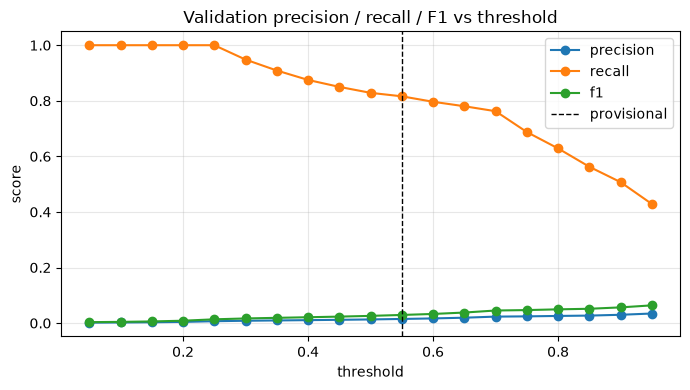

,split,threshold,average_precision,roc_auc,precision,recall,f1,predicted_positives,true_positives,false_positives,false_negatives,true_negatives
0,validation,0.550000,0.146530,0.961583,0.014941,0.816071,0.029346,30586,457,30129,103,384939


In [ ]:
thresh_table = threshold_analysis(y_val, val_proba)
provisional_threshold, threshold_reason = select_provisional_threshold(thresh_table)

print(f"Provisional threshold: {provisional_threshold}")
print(threshold_reason)
display(thresh_table)

fig, ax = plt.subplots()
ax.plot(thresh_table["threshold"], thresh_table["precision"], marker="o", label="precision")
ax.plot(thresh_table["threshold"], thresh_table["recall"], marker="o", label="recall")
ax.plot(thresh_table["threshold"], thresh_table["f1"], marker="o", label="f1")
ax.axvline(provisional_threshold, color="black", linestyle="--", linewidth=1, label="provisional")
ax.set_xlabel("threshold")
ax.set_ylabel("score")
ax.set_title("Validation precision / recall / F1 vs threshold")
ax.legend()
plt.tight_layout()
plt.show()

val_final = classification_metrics_at_threshold(
    y_val, val_proba, threshold=provisional_threshold
)
pd.DataFrame([{"split": "validation", **{k: val_final[k] for k in (
    "threshold", "average_precision", "roc_auc", "precision", "recall", "f1",
    "predicted_positives", "true_positives", "false_positives",
    "false_negatives", "true_negatives",
)}}])

## 8. Final Test Performance

Evaluate the untouched test set **once** with the frozen provisional threshold from validation.

,split,threshold,average_precision,roc_auc,precision,recall,f1,predicted_positives
0,test,0.550000,0.376436,0.956973,0.084174,0.819900,0.152674,39157


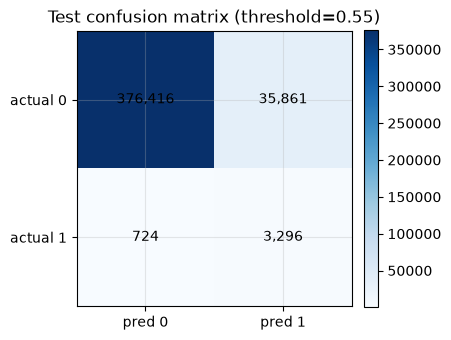

TN=376,416  FP=35,861  FN=724  TP=3,296


In [ ]:
test_final = classification_metrics_at_threshold(
    y_test, test_proba, threshold=provisional_threshold
)

test_metrics_df = pd.DataFrame(
    [
        {
            "split": "test",
            "threshold": test_final["threshold"],
            "average_precision": test_final["average_precision"],
            "roc_auc": test_final["roc_auc"],
            "precision": test_final["precision"],
            "recall": test_final["recall"],
            "f1": test_final["f1"],
            "predicted_positives": test_final["predicted_positives"],
        }
    ]
)
display(test_metrics_df)

cm = [
    [test_final["true_negatives"], test_final["false_positives"]],
    [test_final["false_negatives"], test_final["true_positives"]],
]
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], labels=["pred 0", "pred 1"])
ax.set_yticks([0, 1], labels=["actual 0", "actual 1"])
ax.set_title(f"Test confusion matrix (threshold={provisional_threshold})")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i][j]:,}", ha="center", va="center", color="black")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

print(
    f"TN={test_final['true_negatives']:,}  FP={test_final['false_positives']:,}  "
    f"FN={test_final['false_negatives']:,}  TP={test_final['true_positives']:,}"
)

## 9. Conclusions

- **Useful signal?** The ranking metrics (especially PR-AUC relative to the tiny fraud base rate) indicate whether this three-feature baseline carries non-trivial signal before authorization. Inspect the validation/test tables above rather than treating the model as production-ready.
- **Class imbalance** remains severe even after restricting to TRANSFER/CASH_OUT; accuracy would be misleading, which is why PR-AUC, precision, and recall are primary. Class-weighted training also means scores are not yet calibrated probabilities.
- **Prevalence through time:** after correcting the split to ~70/15/15 of rows, compare fraud rates in the summary table. Material differences between train, validation, and test are an empirical characteristic of PaySim under chronological evaluation — report them; do not hide them.
- **Baseline limits:** no account history, no destination context, no engineered velocity features; `oldbalanceOrg` availability in a real auth path still needs product confirmation; IDs and post-transaction fields were correctly excluded.
- **Next to test:** richer leakage-safe features (past-only aggregates), stronger tabular models (e.g. gradient boosting) under the same temporal protocol, probability calibration, and cost-aware threshold policies — still without claiming production readiness.

This notebook establishes a reproducible, leakage-aware baseline only. It is **not** a production fraud system.